In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/arichter/Documents/GitHub/be-fair/evaluation/MEDFAIR_evaluations/AIDE_individual_runs.csv")

label_map = {
    "basic_prompt": "Basic",
    "addition_1": "Addition 1",
    "addition_2": "Addition 2",
    "addition_3": "Addition 3",
}
df["Prompt"] = df["prompt"].map(label_map)
df["Fairness_Gap"] = df["Test Overall AUC"] - df["Test worst_auc"]
PROMPT_ORDER = ["Basic", "Addition 1", "Addition 2", "Addition 3"]

sns.set_theme(style="whitegrid", font_scale=1.2)
PALETTE = sns.color_palette("Set2", 4)

print(f"Loaded {len(df)} runs across {df['prompt'].nunique()} prompt versions")
df.groupby("Prompt")[["Test Overall AUC", "Test worst_auc", "Fairness_Gap"]].agg(["mean", "std"]).round(3)

Loaded 27 runs across 4 prompt versions


Test Overall AUC        Test worst_auc        Fairness_Gap       
                       mean    std           mean    std         mean    std
Prompt                                                                      
Addition 1            0.586  0.034          0.507  0.039        0.079  0.021
Addition 2            0.622  0.039          0.523  0.017        0.098  0.025
Addition 3            0.583  0.018          0.487  0.032        0.096  0.025
Basic                 0.613  0.039          0.521  0.070        0.092  0.040

/var/folders/3c/dcttlhxn3gnbm4f60bmb6ys00000gn/T/ipykernel_13529/2063556327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Prompt", y="Test Overall AUC", order=PROMPT_ORDER,
/var/folders/3c/dcttlhxn3gnbm4f60bmb6ys00000gn/T/ipykernel_13529/2063556327.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Prompt", y="AUC_Difference", order=PROMPT_ORDER,


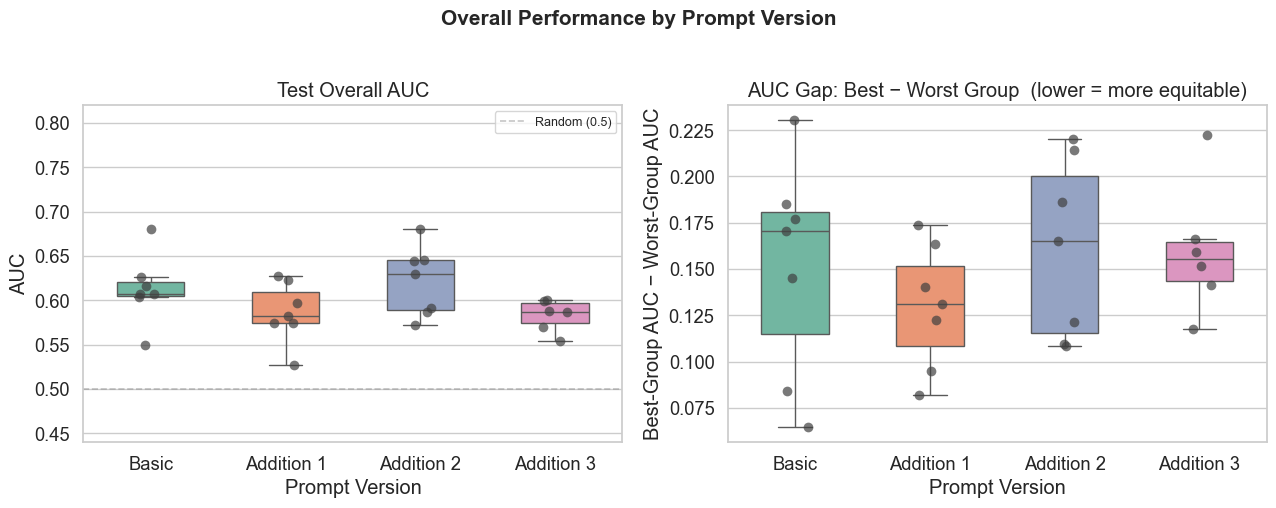

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Overall AUC ---
sns.boxplot(data=df, x="Prompt", y="Test Overall AUC", order=PROMPT_ORDER,
            palette=PALETTE, width=0.5, fliersize=0, ax=axes[0])
sns.stripplot(data=df, x="Prompt", y="Test Overall AUC", order=PROMPT_ORDER,
              color=".25", alpha=0.7, jitter=True, size=7, ax=axes[0])
axes[0].set_ylim(0.44, 0.82)
axes[0].set_xlabel("Prompt Version")
axes[0].set_ylabel("AUC")
axes[0].set_title("Test Overall AUC")
axes[0].axhline(0.5, color="grey", linestyle="--", alpha=0.45, linewidth=1.2, label="Random (0.5)")
axes[0].legend(fontsize=9)

# --- AUC spread: best group AUC − worst group AUC ---
sns.boxplot(data=df, x="Prompt", y="AUC_Difference", order=PROMPT_ORDER,
            palette=PALETTE, width=0.5, fliersize=0, ax=axes[1])
sns.stripplot(data=df, x="Prompt", y="AUC_Difference", order=PROMPT_ORDER,
              color=".25", alpha=0.7, jitter=True, size=7, ax=axes[1])
axes[1].set_xlabel("Prompt Version")
axes[1].set_ylabel("Best-Group AUC − Worst-Group AUC")
axes[1].set_title("AUC Gap: Best − Worst Group  (lower = more equitable)")

plt.suptitle("Overall Performance by Prompt Version", fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

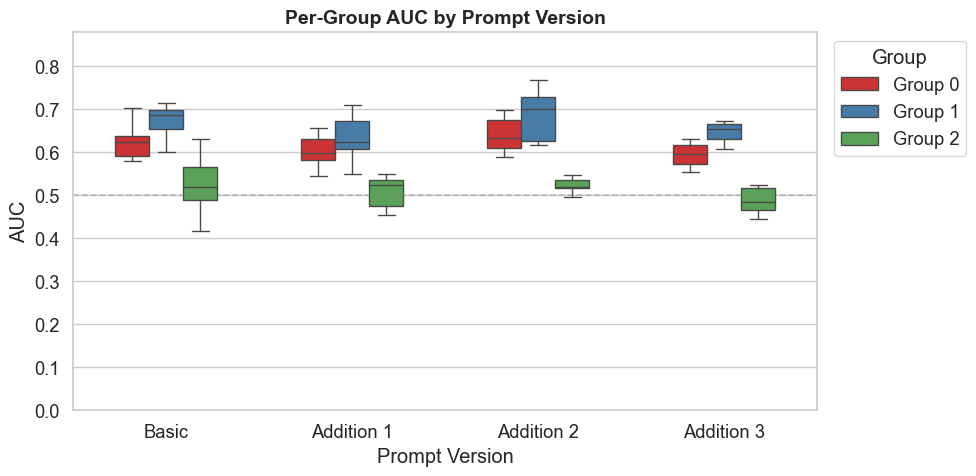

In [15]:
group_col_map = {
    "Test auc-group_0": "Group 0",
    "Test auc-group_1": "Group 1",
    "Test auc-group_2": "Group 2",
}
df_auc = (
    df[["Prompt"] + list(group_col_map.keys())]
    .melt(id_vars="Prompt", var_name="_col", value_name="AUC")
)
df_auc["Group"] = df_auc["_col"].map(group_col_map)

GROUP_PALETTE = sns.color_palette("Set1", 3)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_auc, x="Prompt", y="AUC", hue="Group", order=PROMPT_ORDER,
            palette=GROUP_PALETTE, width=0.55, fliersize=0, ax=ax)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.45, linewidth=1.2)
ax.set_ylim(0.0, 0.88)
ax.set_xlabel("Prompt Version")
ax.set_ylabel("AUC")
ax.set_title("Per-Group AUC by Prompt Version", fontsize=14, fontweight="bold")
ax.legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

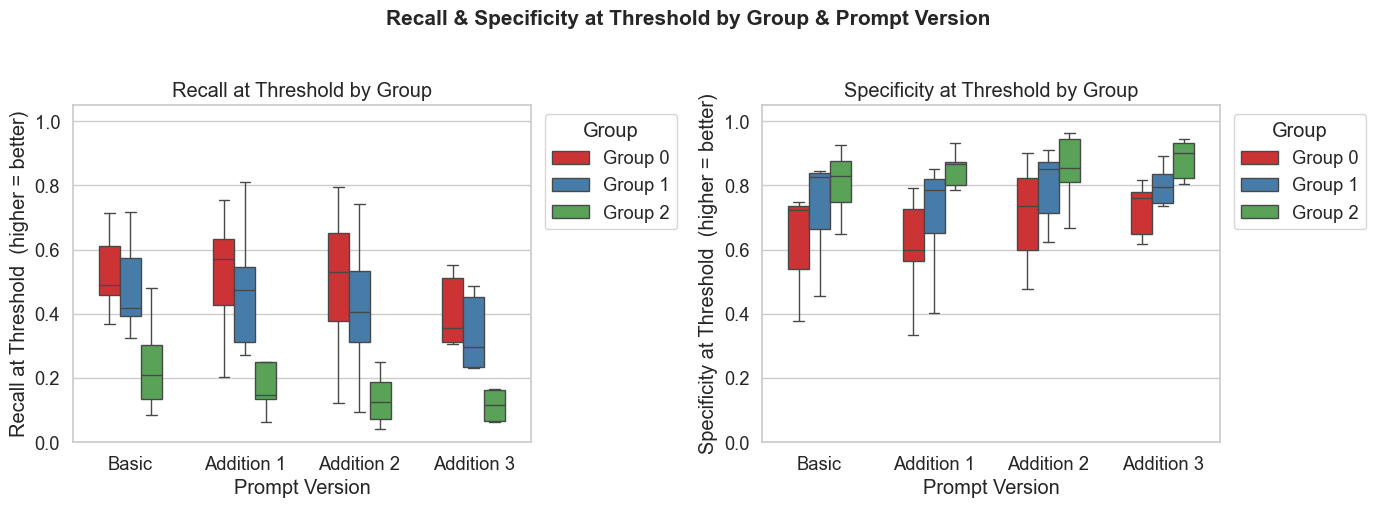

In [16]:
recall_map = {
    "Test recall_at_thres-group_0": "Group 0",
    "Test recall_at_thres-group_1": "Group 1",
    "Test recall_at_thres-group_2": "Group 2",
}
spec_map = {
    "Test specificity_at_thres-group_0": "Group 0",
    "Test specificity_at_thres-group_1": "Group 1",
    "Test specificity_at_thres-group_2": "Group 2",
}

df_recall = (
    df[["Prompt"] + list(recall_map.keys())]
    .melt(id_vars="Prompt", var_name="_c", value_name="Recall")
)
df_recall["Group"] = df_recall["_c"].map(recall_map)

df_spec = (
    df[["Prompt"] + list(spec_map.keys())]
    .melt(id_vars="Prompt", var_name="_c", value_name="Specificity")
)
df_spec["Group"] = df_spec["_c"].map(spec_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_recall, x="Prompt", y="Recall", hue="Group", order=PROMPT_ORDER,
            palette=GROUP_PALETTE, width=0.55, fliersize=0, ax=axes[0])
axes[0].set_title("Recall at Threshold by Group")
axes[0].set_xlabel("Prompt Version")
axes[0].set_ylabel("Recall at Threshold  (higher = better)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left")

sns.boxplot(data=df_spec, x="Prompt", y="Specificity", hue="Group", order=PROMPT_ORDER,
            palette=GROUP_PALETTE, width=0.55, fliersize=0, ax=axes[1])
axes[1].set_title("Specificity at Threshold by Group")
axes[1].set_xlabel("Prompt Version")
axes[1].set_ylabel("Specificity at Threshold  (higher = better)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Recall & Specificity at Threshold by Group & Prompt Version", fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

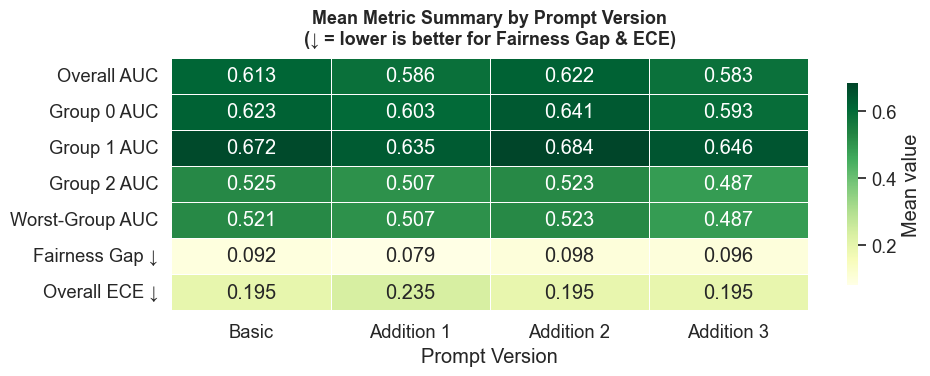

In [17]:
metric_map = {
    "Overall AUC":      "Test Overall AUC",
    "Group 0 AUC":      "Test auc-group_0",
    "Group 1 AUC":      "Test auc-group_1",
    "Group 2 AUC":      "Test auc-group_2",
    "Worst-Group AUC":  "Test worst_auc",
    "Fairness Gap ↓":   "Fairness_Gap",
    "Overall ECE ↓":    "Test Overall ECE",
}

mean_df = (
    df.groupby("Prompt")[[v for v in metric_map.values()]]
    .mean()
    .loc[PROMPT_ORDER]
)
mean_df.columns = list(metric_map.keys())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    mean_df.T, annot=True, fmt=".3f",
    cmap="YlGn", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Mean value", "shrink": 0.8},
)
ax.set_title(
    "Mean Metric Summary by Prompt Version\n(↓ = lower is better for Fairness Gap & ECE)",
    fontsize=13, fontweight="bold", pad=10,
)
ax.set_xlabel("Prompt Version")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

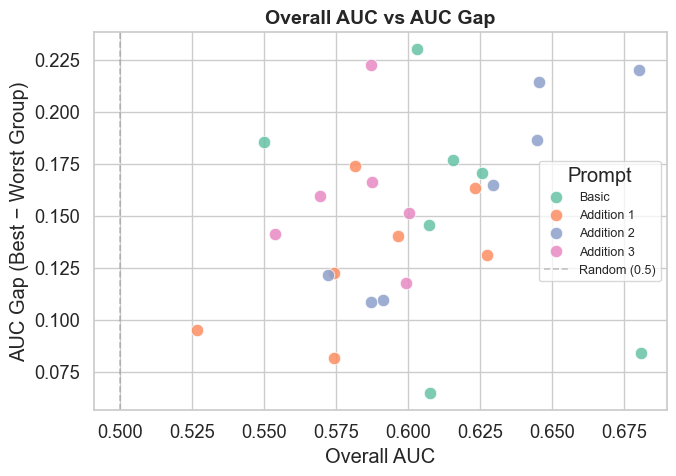

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

for prompt, color in zip(PROMPT_ORDER, PALETTE):
    sub = df[df["Prompt"] == prompt]
    ax.scatter(
        sub["Test Overall AUC"], sub["AUC_Difference"],
        label=prompt, color=color, s=80, alpha=0.85,
        edgecolors="white", linewidths=0.6, zorder=3,
    )

ax.axvline(0.5, color="grey", linestyle="--", alpha=0.45, linewidth=1.2, label="Random (0.5)")
ax.set_xlabel("Overall AUC")
ax.set_ylabel("AUC Gap (Best − Worst Group)")
ax.set_title("Overall AUC vs AUC Gap", fontsize=14, fontweight="bold")
ax.legend(title="Prompt", fontsize=9, framealpha=0.75)
plt.tight_layout()
plt.show()

# AIDE vs. MLZero — Cross-Model Comparison

The cells below load the combined runs (both `AIDE` and `MLZero`) and explore
how the two agent frameworks differ across the same four prompt variants.

In [3]:
df_mm = pd.read_csv(
    "/Users/arichter/Documents/GitHub/be-fair/evaluation/MEDFAIR_evaluations/individual_runs_AIDE_MLZero.csv"
)

df_mm["Prompt"] = df_mm["prompt"].map(label_map)
df_mm["Model"] = df_mm["model"]
df_mm["Fairness_Gap"] = df_mm["Test Overall AUC"] - df_mm["Test worst_auc"]
df_mm["AUC_Spread"]   = df_mm["Test best_auc"]    - df_mm["Test worst_auc"]

MODEL_ORDER   = ["AIDE", "MLZero"]
MODEL_PALETTE = {"AIDE": "#4C72B0", "MLZero": "#DD8452"}

print(f"Loaded {len(df_mm)} runs   |   "
      f"{df_mm['Model'].nunique()} models   |   "
      f"{df_mm['Prompt'].nunique()} prompt versions")

(
    df_mm.groupby(["Model", "Prompt"])[
        ["Test Overall AUC", "Test worst_auc", "Fairness_Gap", "Test Overall ECE"]
    ]
    .mean()
    .round(3)
    .reindex(pd.MultiIndex.from_product([MODEL_ORDER, PROMPT_ORDER], names=["Model", "Prompt"]))
)

Loaded 52 runs   |   2 models   |   4 prompt versions


Test Overall AUC  Test worst_auc  Fairness_Gap  \
Model  Prompt                                                       
AIDE   Basic                  0.613           0.521         0.092   
       Addition 1             0.586           0.507         0.079   
       Addition 2             0.622           0.523         0.098   
       Addition 3             0.583           0.487         0.096   
MLZero Basic                  0.578           0.420         0.158   
       Addition 1             0.588           0.443         0.145   
       Addition 2             0.606           0.494         0.111   
       Addition 3             0.593           0.442         0.152   

                   Test Overall ECE  
Model  Prompt                        
AIDE   Basic                  0.195  
       Addition 1             0.235  
       Addition 2             0.195  
       Addition 3             0.195  
MLZero Basic                  0.391  
       Addition 1             0.329  
       Addition 2             0.282  
       Addition 3             0.257

### 1. Side-by-side: Overall AUC vs. Fairness Gap

Same overall AUC ≠ same fairness. AIDE and MLZero land in a similar AUC band,
but AIDE consistently produces a **smaller worst-group penalty**.

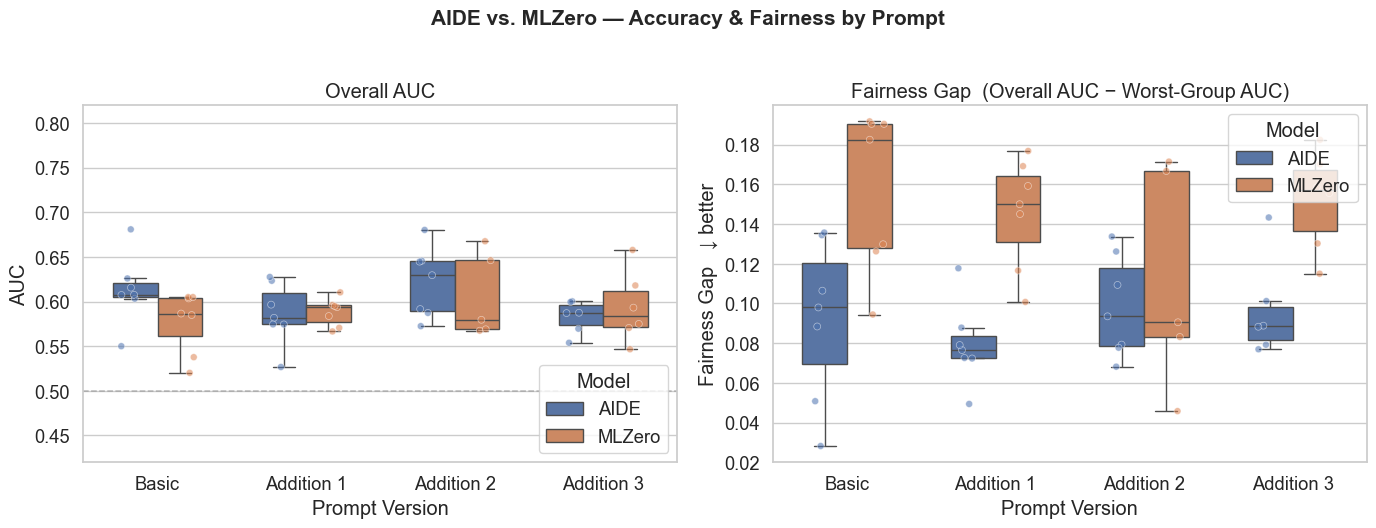

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)

sns.boxplot(
    data=df_mm, x="Prompt", y="Test Overall AUC",
    hue="Model", order=PROMPT_ORDER, hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE, width=0.6, fliersize=0, ax=axes[0],
)
sns.stripplot(
    data=df_mm, x="Prompt", y="Test Overall AUC",
    hue="Model", order=PROMPT_ORDER, hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE, dodge=True, alpha=0.55, size=5,
    edgecolor="white", linewidth=0.5, ax=axes[0], legend=False,
)
axes[0].axhline(0.5, color="grey", linestyle="--", alpha=0.5, linewidth=1.1)
axes[0].set_ylim(0.42, 0.82)
axes[0].set_title("Overall AUC")
axes[0].set_xlabel("Prompt Version")
axes[0].set_ylabel("AUC")
axes[0].legend(title="Model", loc="lower right")

sns.boxplot(
    data=df_mm, x="Prompt", y="Fairness_Gap",
    hue="Model", order=PROMPT_ORDER, hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE, width=0.6, fliersize=0, ax=axes[1],
)
sns.stripplot(
    data=df_mm, x="Prompt", y="Fairness_Gap",
    hue="Model", order=PROMPT_ORDER, hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE, dodge=True, alpha=0.55, size=5,
    edgecolor="white", linewidth=0.5, ax=axes[1], legend=False,
)
axes[1].set_title("Fairness Gap  (Overall AUC − Worst-Group AUC)")
axes[1].set_xlabel("Prompt Version")
axes[1].set_ylabel("Fairness Gap   ↓ better")
axes[1].legend(title="Model", loc="upper right")

plt.suptitle("AIDE vs. MLZero — Accuracy & Fairness by Prompt",
             fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

### 2. Calibration tells a different story

While AUC is similar, **MLZero is dramatically miscalibrated** on the basic
prompt (ECE ≈ 0.39). Each successive prompt addition steadily improves its
calibration — an effect that is almost absent in AIDE, which is already well-
calibrated to begin with.

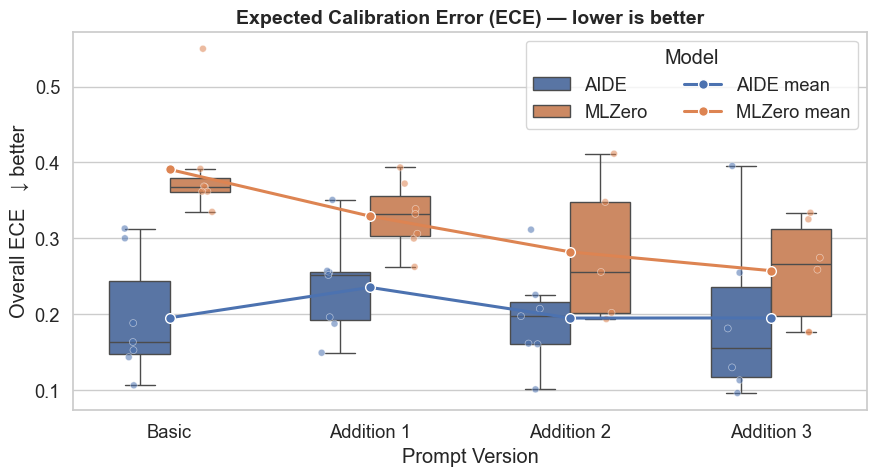

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df_mm, x="Prompt", y="Test Overall ECE",
    hue="Model", order=PROMPT_ORDER, hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE, width=0.6, fliersize=0, ax=ax,
)
sns.stripplot(
    data=df_mm, x="Prompt", y="Test Overall ECE",
    hue="Model", order=PROMPT_ORDER, hue_order=MODEL_ORDER,
    palette=MODEL_PALETTE, dodge=True, alpha=0.55, size=5,
    edgecolor="white", linewidth=0.5, ax=ax, legend=False,
)

mean_lines = (
    df_mm.groupby(["Model", "Prompt"])["Test Overall ECE"].mean().unstack()[PROMPT_ORDER]
)
for model, color in MODEL_PALETTE.items():
    ax.plot(
        range(len(PROMPT_ORDER)),
        mean_lines.loc[model].values,
        color=color, linewidth=2.2, marker="o", markersize=7,
        markeredgecolor="white", zorder=5, label=f"{model} mean",
    )

ax.set_title("Expected Calibration Error (ECE) — lower is better",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Prompt Version")
ax.set_ylabel("Overall ECE   ↓ better")
ax.legend(title="Model", loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

### 3. Where the gap lives — per-group AUC across both models

Splitting the AUC by subgroup shows that **MLZero's higher gap is driven by a
weaker Group 2** in particular, while AIDE balances the three subgroups more
evenly.

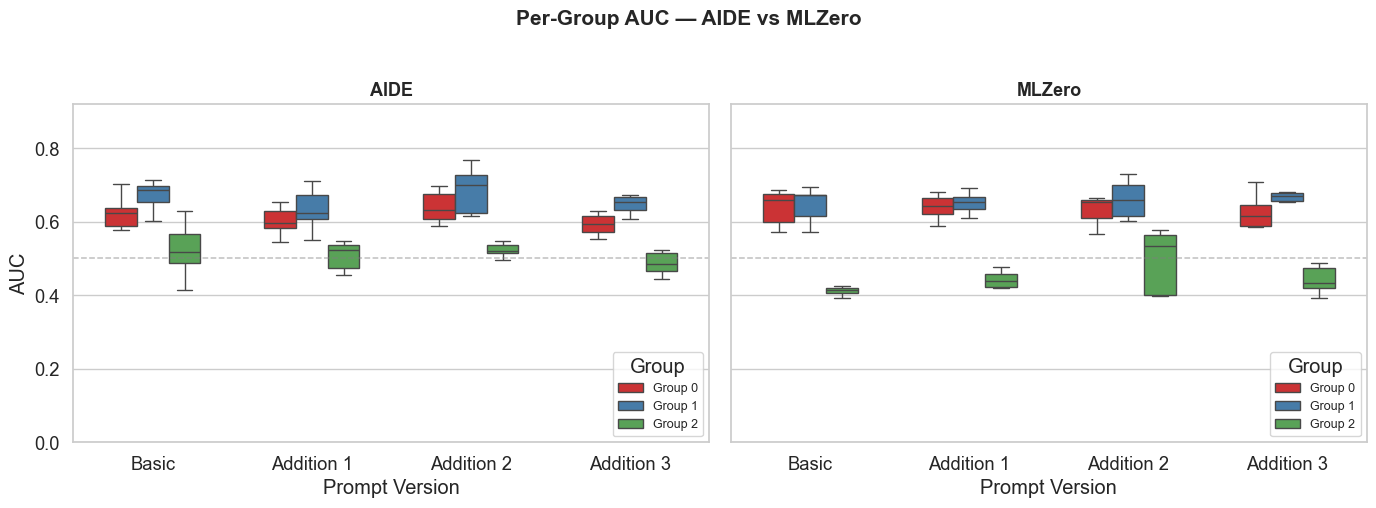

In [6]:
group_cols = {
    "Test auc-group_0": "Group 0",
    "Test auc-group_1": "Group 1",
    "Test auc-group_2": "Group 2",
}
df_groups = (
    df_mm[["Model", "Prompt"] + list(group_cols)]
    .melt(id_vars=["Model", "Prompt"], var_name="_c", value_name="AUC")
)
df_groups["Group"] = df_groups["_c"].map(group_cols)

GROUP_PALETTE = sns.color_palette("Set1", 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    sub = df_groups[df_groups["Model"] == model]
    sns.boxplot(
        data=sub, x="Prompt", y="AUC", hue="Group",
        order=PROMPT_ORDER, palette=GROUP_PALETTE,
        width=0.6, fliersize=0, ax=ax,
    )
    ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, linewidth=1.1)
    ax.set_title(model, fontsize=13, fontweight="bold")
    ax.set_xlabel("Prompt Version")
    ax.set_ylabel("AUC")
    ax.set_ylim(0.0, 0.92)
    ax.legend(title="Group", loc="lower right", fontsize=9)

plt.suptitle("Per-Group AUC — AIDE vs MLZero", fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

### 4. Trade-off view — Accuracy vs. Fairness

Each point is a single run. The ideal region is the **top-left**: high overall
AUC and a small fairness gap. AIDE runs cluster further into that ideal region
than MLZero, even when their overall AUC overlaps.

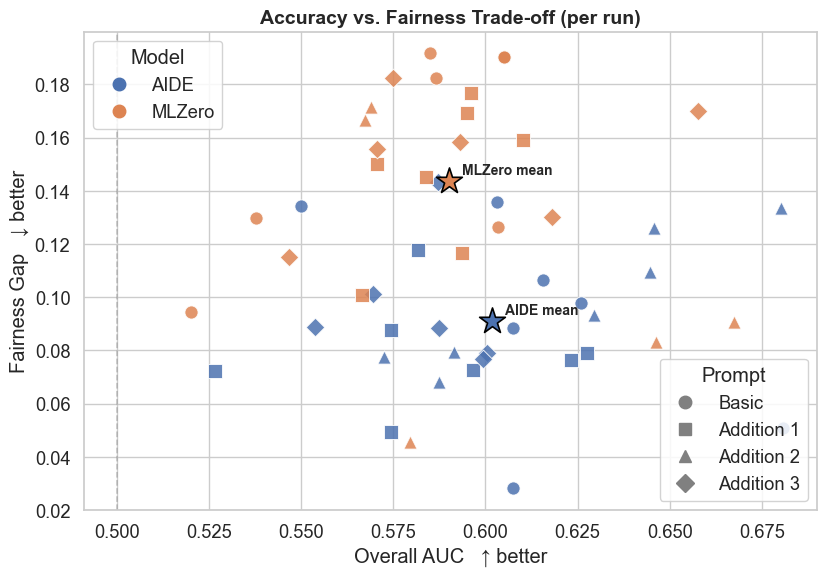

In [7]:
PROMPT_MARKERS = {"Basic": "o", "Addition 1": "s", "Addition 2": "^", "Addition 3": "D"}

fig, ax = plt.subplots(figsize=(8.5, 6))

for model in MODEL_ORDER:
    for prompt in PROMPT_ORDER:
        sub = df_mm[(df_mm["Model"] == model) & (df_mm["Prompt"] == prompt)]
        ax.scatter(
            sub["Test Overall AUC"], sub["Fairness_Gap"],
            color=MODEL_PALETTE[model], marker=PROMPT_MARKERS[prompt],
            s=90, alpha=0.85, edgecolors="white", linewidths=0.7, zorder=3,
        )

means = df_mm.groupby("Model")[["Test Overall AUC", "Fairness_Gap"]].mean()
for model, row in means.iterrows():
    ax.scatter(
        row["Test Overall AUC"], row["Fairness_Gap"],
        color=MODEL_PALETTE[model], marker="*", s=380,
        edgecolors="black", linewidths=1.2, zorder=5,
    )
    ax.annotate(
        f"{model} mean", (row["Test Overall AUC"], row["Fairness_Gap"]),
        xytext=(10, 5), textcoords="offset points", fontsize=10, fontweight="bold",
    )

ax.axvline(0.5, color="grey", linestyle="--", alpha=0.45, linewidth=1.1)
ax.set_xlabel("Overall AUC   ↑ better")
ax.set_ylabel("Fairness Gap   ↓ better")
ax.set_title("Accuracy vs. Fairness Trade-off (per run)", fontsize=14, fontweight="bold")

model_legend = [plt.Line2D([0], [0], marker="o", linestyle="",
                           color=MODEL_PALETTE[m], markersize=9, label=m)
                for m in MODEL_ORDER]
prompt_legend = [plt.Line2D([0], [0], marker=PROMPT_MARKERS[p], linestyle="",
                            color="grey", markersize=9, label=p)
                 for p in PROMPT_ORDER]
leg1 = ax.legend(handles=model_legend, title="Model", loc="upper left", framealpha=0.85)
ax.add_artist(leg1)
ax.legend(handles=prompt_legend, title="Prompt", loc="lower right", framealpha=0.85)

plt.tight_layout()
plt.show()

### 5. Heatmap summary — what does each prompt buy each model?

Annotated cell values are means. The colour scale is normalised **per row**
(per metric) so the *relative* effect of each prompt is comparable across
metrics, even though the metrics live on very different scales.

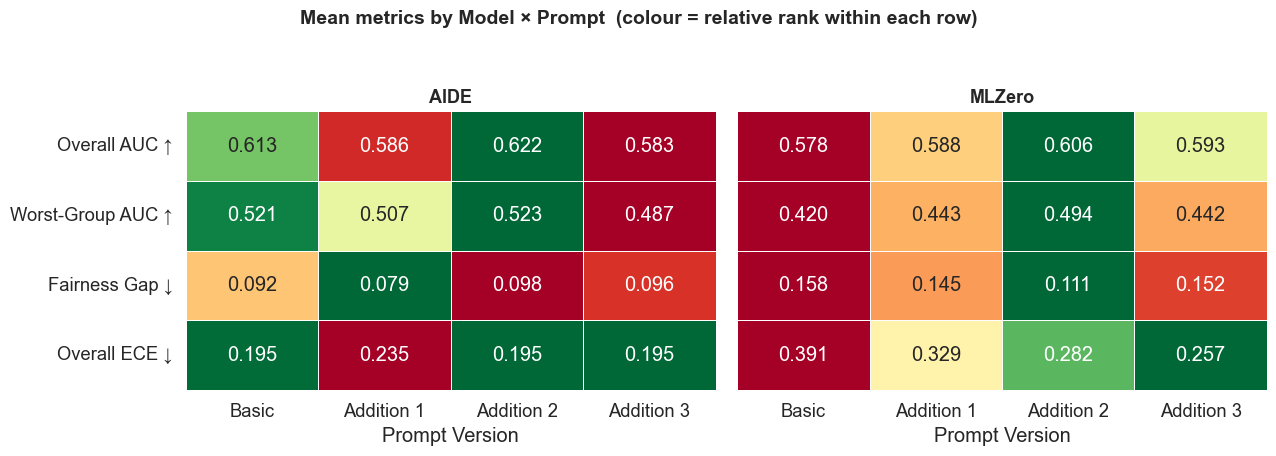

In [8]:
metric_map = {
    "Overall AUC ↑":      "Test Overall AUC",
    "Worst-Group AUC ↑":  "Test worst_auc",
    "Fairness Gap ↓":     "Fairness_Gap",
    "Overall ECE ↓":      "Test Overall ECE",
}
lower_is_better = {"Fairness Gap ↓", "Overall ECE ↓"}

agg = (
    df_mm.groupby(["Model", "Prompt"])[list(metric_map.values())].mean()
        .rename(columns={v: k for k, v in metric_map.items()})
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    block = agg.loc[model].reindex(PROMPT_ORDER)[list(metric_map.keys())].T

    norm = block.copy().astype(float)
    for row in norm.index:
        r = norm.loc[row]
        if row in lower_is_better:
            norm.loc[row] = (r.max() - r) / (r.max() - r.min() + 1e-9)
        else:
            norm.loc[row] = (r - r.min()) / (r.max() - r.min() + 1e-9)

    sns.heatmap(
        norm, annot=block, fmt=".3f",
        cmap="RdYlGn", vmin=0, vmax=1,
        linewidths=0.6, ax=ax, cbar=False,
    )
    ax.set_title(model, fontsize=13, fontweight="bold")
    ax.set_xlabel("Prompt Version")
    ax.set_ylabel("")

plt.suptitle("Mean metrics by Model × Prompt  (colour = relative rank within each row)",
             fontsize=14, y=1.04, fontweight="bold")
plt.tight_layout()
plt.show()

### 6. Direct head-to-head deltas

What does switching from MLZero → AIDE actually win or lose? Negative bars on
ECE / Fairness Gap mean AIDE is better; positive bars on AUC metrics mean
AIDE is better.

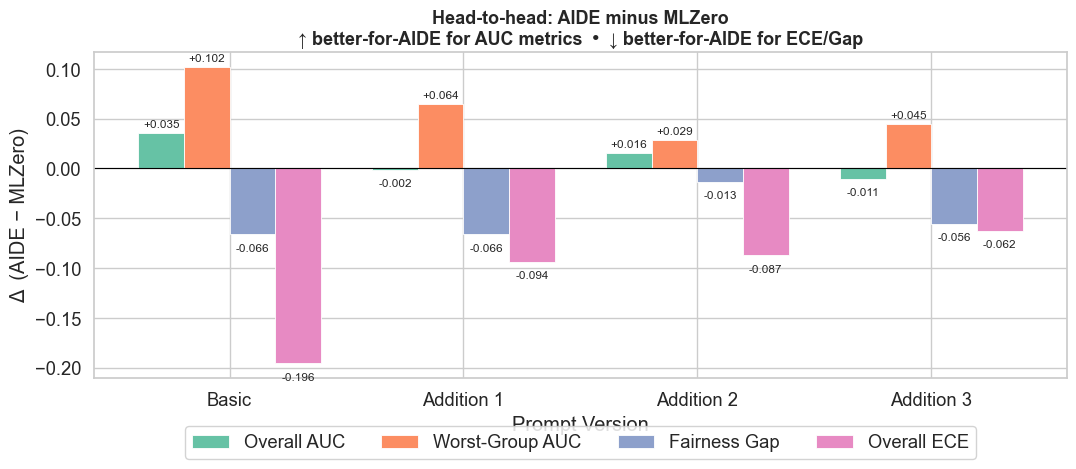

In [9]:
delta_metrics = {
    "Overall AUC":     "Test Overall AUC",
    "Worst-Group AUC": "Test worst_auc",
    "Fairness Gap":    "Fairness_Gap",
    "Overall ECE":     "Test Overall ECE",
}
means = df_mm.groupby(["Model", "Prompt"])[list(delta_metrics.values())].mean()
deltas = (means.loc["AIDE"] - means.loc["MLZero"]).reindex(PROMPT_ORDER)
deltas.columns = list(delta_metrics.keys())

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(PROMPT_ORDER))
n = len(delta_metrics)
width = 0.78 / n
colors = sns.color_palette("Set2", n)

for i, (metric, color) in enumerate(zip(deltas.columns, colors)):
    offsets = x + (i - (n - 1) / 2) * width
    bars = ax.bar(offsets, deltas[metric].values, width=width,
                  label=metric, color=color, edgecolor="white", linewidth=0.6)
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:+.03f}", (b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 4 if h >= 0 else -12), textcoords="offset points",
                    ha="center", fontsize=8.5)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(PROMPT_ORDER)
ax.set_xlabel("Prompt Version")
ax.set_ylabel("Δ  (AIDE − MLZero)")
ax.set_title("Head-to-head: AIDE minus MLZero\n"
             "↑ better-for-AIDE for AUC metrics  •  ↓ better-for-AIDE for ECE/Gap",
             fontsize=13, fontweight="bold")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), framealpha=0.85)
plt.tight_layout()
plt.show()

# Putting it in context — MEDFAIR baselines & human dermatologists

The aggregated CSV reports `mean`, `std`, `ci95_hi`, `ci95_lo` for each
`(model, prompt)` and adds two reference families:

- **Baseline** — MEDFAIR baseline runs on Fitzpatrick17k variants
  (`Fitzpatrick17kC_binary`, `Fitzpatrick_17kC`, `Full_fitz17k`).
- **human** — dermatologist performance on the same task
  (`dermatologists`).

The cells below load that file and place AIDE / MLZero on the same axes as
those references so we can see whether the agents are close to (or above)
trained-baseline / human performance.

In [10]:
df_agg_raw = pd.read_csv(
    "/Users/arichter/Documents/GitHub/be-fair/evaluation/MEDFAIR_evaluations/"
    "AIDE_MLZero_Baseline_Human_aggregated.csv",
    index_col=0,
)

prompt_label_full = {
    "basic_prompt": "Basic",     "addition_1": "Addition 1",
    "addition_2":   "Addition 2", "addition_3": "Addition 3",
    "mlzero_bp":    "Basic",     "mlzero_add1": "Addition 1",
    "mlzero_add2":  "Addition 2", "mlzero_add3": "Addition 3",
    "Fitzpatrick17kC_binary": "Fitzpatrick17kC (binary)",
    "Fitzpatrick_17kC":       "Fitzpatrick17kC",
    "Full_fitz17k":           "Full Fitzpatrick17k",
    "dermatologists":         "Dermatologists",
}

def pivot_stat(stat_name):
    sub = df_agg_raw[df_agg_raw["statistic"] == stat_name].copy()
    sub["Prompt"] = sub["prompt"].map(prompt_label_full).fillna(sub["prompt"])
    sub["Config"] = sub["model"] + " — " + sub["Prompt"]
    sub = sub.drop(columns=["statistic", "model", "prompt"]).set_index("Config")
    return sub

mean_df      = pivot_stat("mean")
ci_lo_df     = pivot_stat("ci95_lo")
ci_hi_df     = pivot_stat("ci95_hi")

mean_df["Fairness_Gap"]  = mean_df["Test Overall AUC"] - mean_df["Test worst_auc"]
ci_lo_df["Fairness_Gap"] = ci_lo_df["Test Overall AUC"] - ci_lo_df["Test worst_auc"]
ci_hi_df["Fairness_Gap"] = ci_hi_df["Test Overall AUC"] - ci_hi_df["Test worst_auc"]

mean_df["Model"]  = [c.split(" — ")[0] for c in mean_df.index]
mean_df["Prompt"] = [c.split(" — ")[1] for c in mean_df.index]

print(f"{len(mean_df)} (model, prompt) groups   "
      f"across {mean_df['Model'].nunique()} model families")
mean_df[["Model", "Prompt", "Test Overall AUC", "Test worst_auc",
         "Fairness_Gap", "Test Overall ECE"]].round(3)

12 (model, prompt) groups   across 4 model families


,Model,Prompt,Test Overall AUC,Test worst_auc,Fairness_Gap,Test Overall ECE
Config,,,,,,
AIDE — Addition 1,AIDE,Addition 1,0.586,0.507,0.079,0.235
AIDE — Addition 2,AIDE,Addition 2,0.622,0.523,0.098,0.195
AIDE — Addition 3,AIDE,Addition 3,0.583,0.487,0.096,0.195
AIDE — Basic,AIDE,Basic,0.613,0.521,0.092,0.195
MLZero — Addition 1,MLZero,Addition 1,0.588,0.443,0.145,0.329
MLZero — Addition 2,MLZero,Addition 2,0.606,0.494,0.111,0.282
MLZero — Addition 3,MLZero,Addition 3,0.593,0.442,0.152,0.257
MLZero — Basic,MLZero,Basic,0.578,0.420,0.158,0.391
Baseline — Fitzpatrick17kC (binary),Baseline,Fitzpatrick17kC (binary),0.678,0.592,0.086,0.286


### 7. Overall AUC vs. trained baselines & human dermatologists

Horizontal bars with 95 % CIs make it easy to compare every configuration on
the same scale. Dashed vertical lines mark **MEDFAIR's best Baseline** and
the **human dermatologist** AUC for reference.

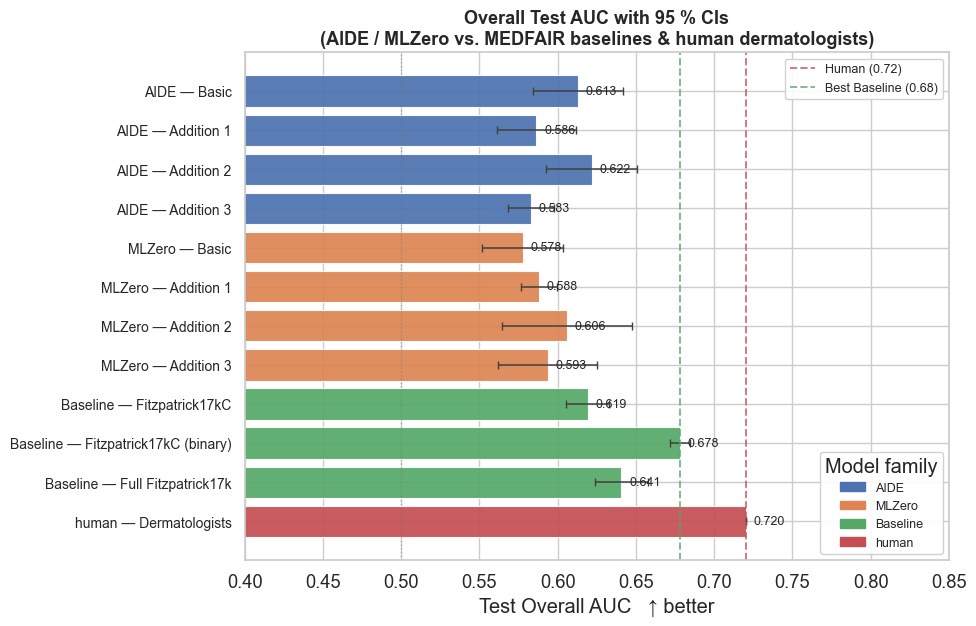

In [11]:
FAMILY_COLOR = {
    "AIDE":     "#4C72B0",
    "MLZero":   "#DD8452",
    "Baseline": "#55A868",
    "human":    "#C44E52",
}

def family_sort_key(cfg):
    fam_order = {"AIDE": 0, "MLZero": 1, "Baseline": 2, "human": 3}
    fam, prompt = cfg.split(" — ", 1)
    prompt_rank = {"Basic": 0, "Addition 1": 1, "Addition 2": 2, "Addition 3": 3}
    return (fam_order.get(fam, 99), prompt_rank.get(prompt, 99), prompt)

metric  = "Test Overall AUC"
plot_df = mean_df.dropna(subset=[metric]).copy()
plot_df = plot_df.loc[sorted(plot_df.index, key=family_sort_key)]

lo_aligned = ci_lo_df[metric].reindex(plot_df.index)
hi_aligned = ci_hi_df[metric].reindex(plot_df.index)
means  = plot_df[metric].values
lo_err = (plot_df[metric] - lo_aligned).clip(lower=0).fillna(0).values
hi_err = (hi_aligned - plot_df[metric]).clip(lower=0).fillna(0).values
colors = [FAMILY_COLOR[m] for m in plot_df["Model"]]

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(plot_df))[::-1]
ax.barh(y, means, xerr=[lo_err, hi_err], color=colors,
        edgecolor="white", linewidth=0.8, alpha=0.92,
        error_kw=dict(ecolor="0.25", lw=1.1, capsize=3))

for yi, val in zip(y, means):
    ax.text(val + 0.005, yi, f"{val:.3f}", va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index, fontsize=10)
ax.set_xlabel("Test Overall AUC   ↑ better")
ax.set_xlim(0.4, max(0.85, means.max() + 0.07))
ax.axvline(0.5, color="grey", linestyle=":", alpha=0.5, linewidth=1)

human_val = mean_df.loc[mean_df["Model"] == "human", metric].max()
baseline_best = mean_df.loc[mean_df["Model"] == "Baseline", metric].max()
if not np.isnan(human_val):
    ax.axvline(human_val, color=FAMILY_COLOR["human"], linestyle="--",
               linewidth=1.4, alpha=0.75, label=f"Human ({human_val:.2f})")
if not np.isnan(baseline_best):
    ax.axvline(baseline_best, color=FAMILY_COLOR["Baseline"], linestyle="--",
               linewidth=1.4, alpha=0.75, label=f"Best Baseline ({baseline_best:.2f})")

family_handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=m)
                  for m, c in FAMILY_COLOR.items()]
leg1 = ax.legend(handles=family_handles, title="Model family",
                 loc="lower right", framealpha=0.9, fontsize=9)
ax.add_artist(leg1)
ax.legend(loc="upper right", framealpha=0.9, fontsize=9)

ax.set_title("Overall Test AUC with 95 % CIs\n(AIDE / MLZero vs. MEDFAIR baselines & human dermatologists)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 8. Accuracy *and* fairness in one chart

Each configuration becomes a point in (Overall AUC, Worst-Group AUC) space.
The grey diagonal is the **equality line** — points on it would treat every
subgroup identically. The further below the line, the larger the worst-case
penalty. Trained baselines and dermatologists cluster in the upper-right
"high accuracy + high worst-group" region; the LLM-agent runs sit lower-left.

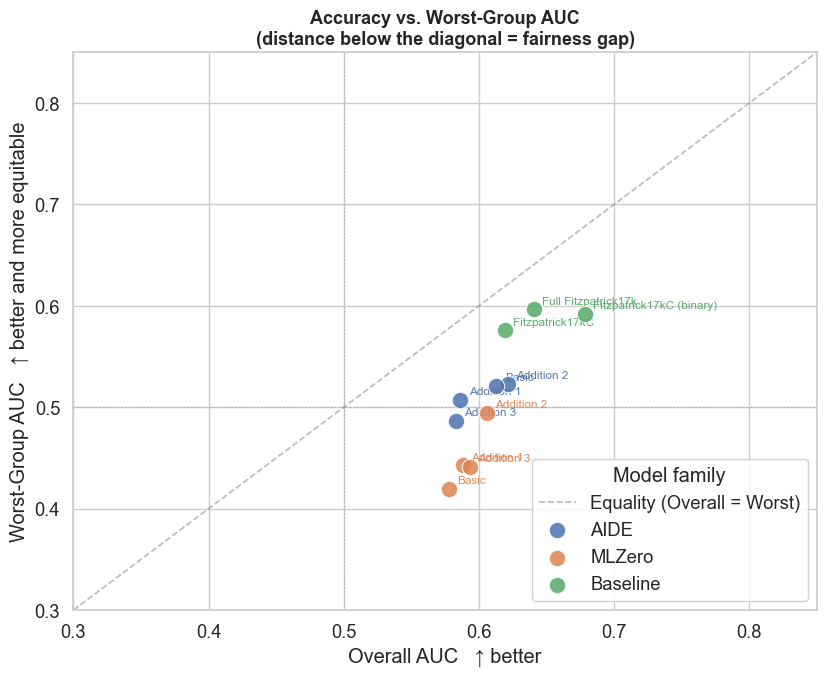

In [12]:
scatter_df = mean_df.dropna(subset=["Test Overall AUC", "Test worst_auc"]).copy()

fig, ax = plt.subplots(figsize=(8.5, 7))

lims = [0.30, 0.85]
ax.plot(lims, lims, color="grey", linestyle="--", alpha=0.55, linewidth=1.2,
        label="Equality (Overall = Worst)")
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.35, linewidth=1)
ax.axvline(0.5, color="grey", linestyle=":", alpha=0.35, linewidth=1)

for fam, color in FAMILY_COLOR.items():
    sub = scatter_df[scatter_df["Model"] == fam]
    if sub.empty:
        continue
    ax.scatter(sub["Test Overall AUC"], sub["Test worst_auc"],
               color=color, s=140, alpha=0.85, edgecolors="white",
               linewidths=0.8, zorder=4, label=fam)
    for cfg, row in sub.iterrows():
        ax.annotate(row["Prompt"],
                    (row["Test Overall AUC"], row["Test worst_auc"]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=8.5, color=color, alpha=0.95)

ax.set_xlim(*lims)
ax.set_ylim(*lims)
ax.set_xlabel("Overall AUC   ↑ better")
ax.set_ylabel("Worst-Group AUC   ↑ better and more equitable")
ax.set_title("Accuracy vs. Worst-Group AUC\n(distance below the diagonal = fairness gap)",
             fontsize=13, fontweight="bold")
ax.legend(title="Model family", loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.show()

### 9. Per-group AUC across every configuration

The same picture, but broken out by skin-tone group. Dashed coloured lines
mark the dermatologist AUC for the two reported groups (Group 0 ≈ 0.75,
Group 2 ≈ 0.62). It's striking how `Baseline` runs match or exceed those
references, while the LLM-agent runs underperform across all groups.

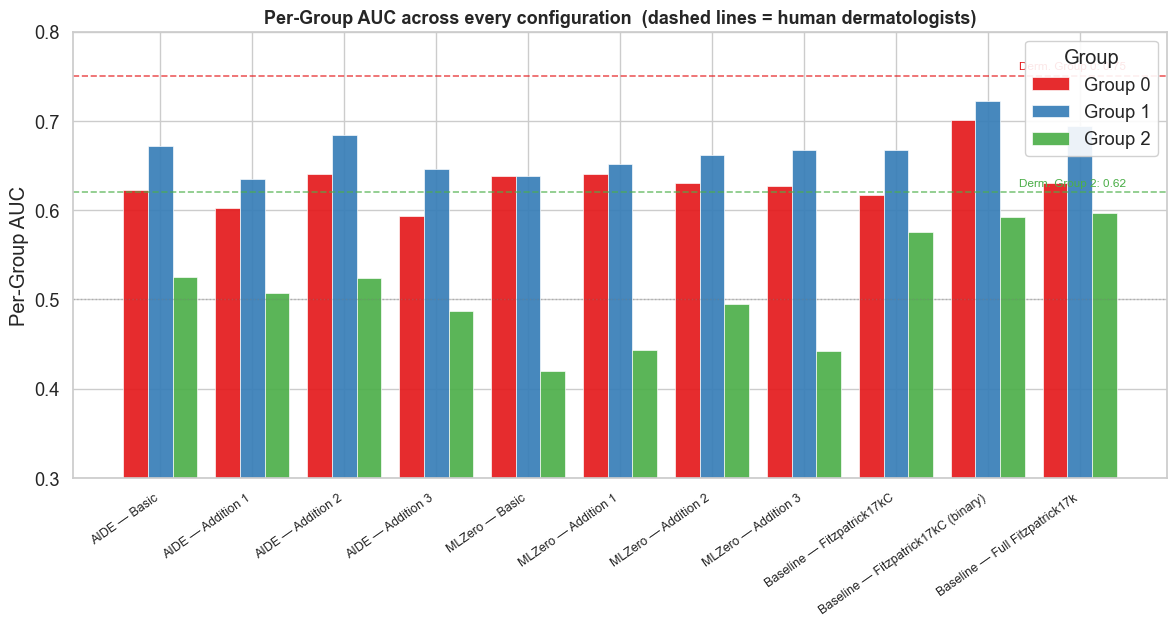

In [13]:
group_cols_agg = {
    "Test auc-group_0": "Group 0",
    "Test auc-group_1": "Group 1",
    "Test auc-group_2": "Group 2",
}

agent_mask = mean_df["Model"].isin(["AIDE", "MLZero", "Baseline"])
order      = sorted(mean_df[agent_mask].index, key=family_sort_key)

long = (
    mean_df.loc[order, list(group_cols_agg)]
    .rename(columns=group_cols_agg)
    .reset_index()
    .melt(id_vars="Config", var_name="Group", value_name="AUC")
)
long["Model"] = long["Config"].str.split(" — ").str[0]
long["Prompt"] = long["Config"].str.split(" — ").str[1]

human_row = mean_df.loc[mean_df["Model"] == "human"]
human_groups = {g: human_row[col].iloc[0] for col, g in group_cols_agg.items()
                if not human_row.empty}

fig, ax = plt.subplots(figsize=(12, 6.5))
group_palette = sns.color_palette("Set1", 3)
group_to_color = {g: group_palette[i] for i, g in enumerate(group_cols_agg.values())}

x = np.arange(len(order))
width = 0.27
for i, group in enumerate(group_cols_agg.values()):
    vals = long[long["Group"] == group].set_index("Config").loc[order, "AUC"].values
    ax.bar(x + (i - 1) * width, vals, width=width,
           color=group_to_color[group], edgecolor="white",
           linewidth=0.5, label=group, alpha=0.92)

for group, color in group_to_color.items():
    val = human_groups.get(group)
    if val is None or np.isnan(val):
        continue
    ax.axhline(val, color=color, linestyle="--", linewidth=1.2, alpha=0.7)
    ax.text(len(order) - 0.5, val + 0.005, f"Derm. {group}: {val:.2f}",
            color=color, fontsize=8.5, ha="right", va="bottom")

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Per-Group AUC")
ax.set_ylim(0.30, 0.80)
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.4, linewidth=1)
ax.set_title("Per-Group AUC across every configuration  "
             "(dashed lines = human dermatologists)", fontsize=13, fontweight="bold")
ax.legend(title="Group", loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

### 10. Fairness leaderboard

Configurations ranked by **fairness gap** (overall AUC minus worst-group
AUC). Lower is better — the closer to zero, the more equitable the model is
across skin-tone groups. Note how `Baseline · Full_fitz17k` even goes
*negative*, meaning its worst subgroup actually outperforms its overall AUC
on average.

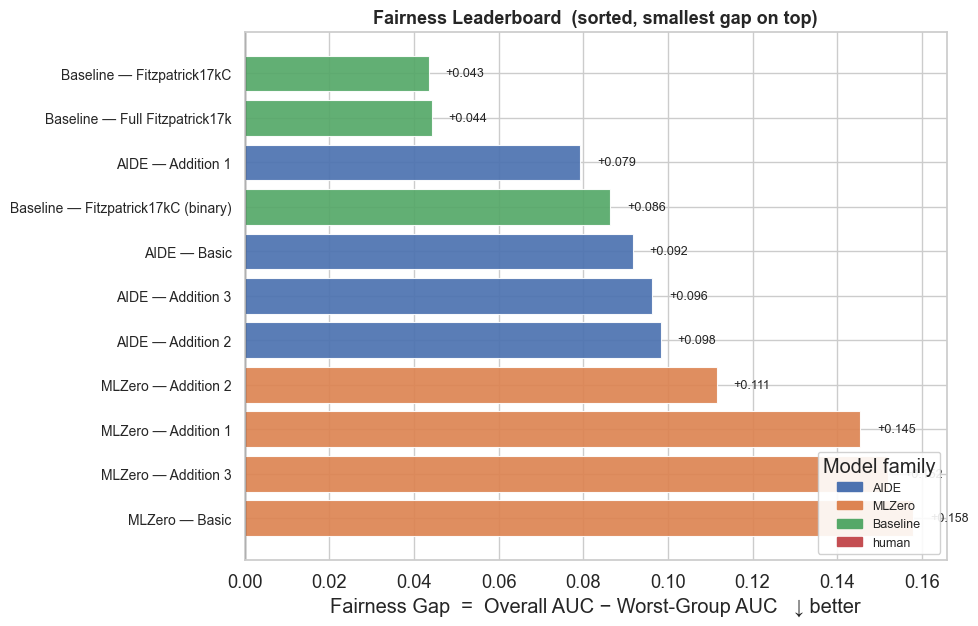

In [14]:
fair_df = (
    mean_df.dropna(subset=["Fairness_Gap"])
    .sort_values("Fairness_Gap", ascending=True)
    .copy()
)

colors = [FAMILY_COLOR[m] for m in fair_df["Model"]]

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(fair_df))[::-1]
bars = ax.barh(y, fair_df["Fairness_Gap"], color=colors,
               edgecolor="white", linewidth=0.8, alpha=0.92)

for bar, val in zip(bars, fair_df["Fairness_Gap"].values):
    offset = 0.004 if val >= 0 else -0.004
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:+.03f}", va="center", ha=ha, fontsize=9)

ax.axvline(0, color="black", linewidth=0.9)
ax.set_yticks(y)
ax.set_yticklabels(fair_df.index, fontsize=10)
ax.set_xlabel("Fairness Gap  =  Overall AUC − Worst-Group AUC   ↓ better")
ax.set_title("Fairness Leaderboard  (sorted, smallest gap on top)",
             fontsize=13, fontweight="bold")

family_handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=m)
                  for m, c in FAMILY_COLOR.items()]
ax.legend(handles=family_handles, title="Model family",
          loc="lower right", framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

### 11. Recall vs. Specificity at threshold — agents vs. dermatologists

Per skin-tone group, where does each model land in the
**recall ↔ specificity** plane? The dermatologist points (red ★) act as a
human reference. Group 0 is "easier" (both humans and models hit higher
recall) while Group 2 is much harder for everyone.

/var/folders/3c/dcttlhxn3gnbm4f60bmb6ys00000gn/T/ipykernel_48735/4097532181.py:29: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/arichter/Documents/miniconda3/envs/be-fair-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


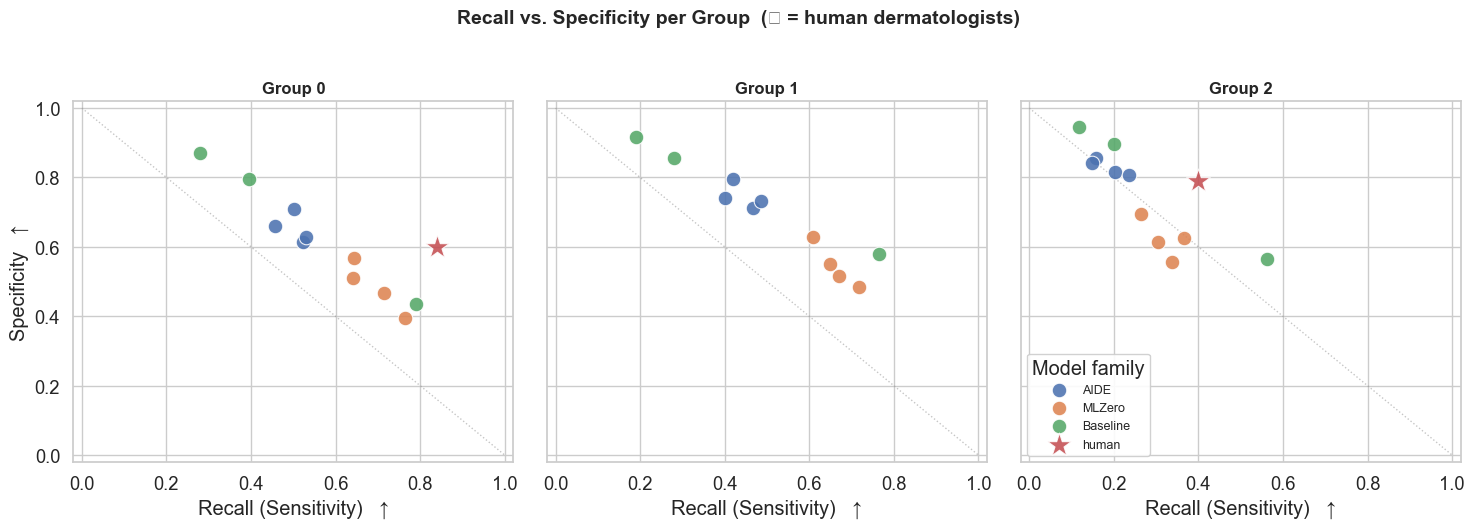

In [15]:
groups = [0, 1, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharex=True, sharey=True)

for ax, g in zip(axes, groups):
    rec_col  = f"Test recall_at_thres-group_{g}"
    spec_col = f"Test specificity_at_thres-group_{g}"

    for fam, color in FAMILY_COLOR.items():
        sub = mean_df[mean_df["Model"] == fam].dropna(subset=[rec_col, spec_col])
        if sub.empty:
            continue
        marker = "*" if fam == "human" else "o"
        size   = 320 if fam == "human" else 110
        ax.scatter(sub[rec_col], sub[spec_col], color=color, marker=marker,
                   s=size, alpha=0.88, edgecolors="white", linewidths=0.8,
                   zorder=4, label=fam)

    ax.plot([0, 1], [1, 0], color="grey", linestyle=":", alpha=0.45, linewidth=1)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Recall (Sensitivity)   ↑")
    ax.set_title(f"Group {g}", fontsize=12, fontweight="bold")
    if g == 0:
        ax.set_ylabel("Specificity   ↑")

axes[-1].legend(title="Model family", loc="lower left", fontsize=9, framealpha=0.9)
plt.suptitle("Recall vs. Specificity per Group  (★ = human dermatologists)",
             fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()